# CycPeptMPDB-4D eda

In [2]:
import pandas as pn
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pn.read_csv('/ssd0/sohyun/cyclic_peptide_permeability/data/CycPeptMPDB-4D_with_SMILES.csv')
df.head()

,CycPeptMPDB_ID,Source,Original_Name_in_Source_Literature,Structurally_Unique_ID,PAMPA-4D,Monomer_Length,Monomer_Length_in_Main_Chain,Molecule_Shape,Water_avgRMSD_All,Water_avgRMSD_BackBone,...,Water_3D_PSA,Hexane_avgRMSD_All,Hexane_avgRMSD_BackBone,Hexane_3D_SASA,Hexane_3D_NPSA,Hexane_3D_PSA,SMILES,HELM,Sequence,PAMPA
0,7067,2021_Kelly,L4_4.4.4.4.1,7067,-5.10,10,9,Lariat,0.133914,0.072443,...,1.532,0.146044,0.080495,11.240,9.771,1.469,CC(=O)N[C@@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](C...,PEPTIDE7067{[ac-].T.P.[Me_dL].[Me_dL].[Me_dL]....,"['ac-', 'T', 'P', 'Me_dL', 'Me_dL', 'Me_dL', '...",-5.10
1,7066,2021_Kelly,L4_4.4.4.3.1,7066,-5.40,10,9,Lariat,0.125209,0.071657,...,1.498,0.118725,0.071054,11.558,10.116,1.442,CC(=O)N[C@@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](C...,PEPTIDE7066{[ac-].T.P.[Me_dL].[Me_dL].[Me_dL]....,"['ac-', 'T', 'P', 'Me_dL', 'Me_dL', 'Me_dL', '...",-5.40
2,7065,2021_Kelly,L4_4.4.3.4.1,7065,-5.47,10,9,Lariat,0.159268,0.090051,...,1.415,0.111265,0.052971,11.264,10.055,1.209,CC(=O)N[C@@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](C...,PEPTIDE7065{[ac-].T.P.[Me_dL].[Me_dL].[Me_dL]....,"['ac-', 'T', 'P', 'Me_dL', 'Me_dL', 'Me_dL', '...",-5.47
3,7064,2021_Kelly,L4_4.4.3.3.1,7064,-5.80,10,9,Lariat,0.139869,0.078185,...,1.684,0.138883,0.072635,11.755,10.103,1.652,CC(=O)N[C@@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](C...,PEPTIDE7064{[ac-].T.P.[Me_dL].[Me_dL].[Me_dL]....,"['ac-', 'T', 'P', 'Me_dL', 'Me_dL', 'Me_dL', '...",-5.80
4,7063,2021_Kelly,L4_4.3.4.4.1,7063,-5.29,10,9,Lariat,0.137568,0.088278,...,1.537,0.121935,0.057907,11.281,9.917,1.364,CC(=O)N[C@@H]1C(=O)N2CCC[C@H]2C(=O)N(C)[C@H](C...,PEPTIDE7063{[ac-].T.P.[Me_dL].[Me_dL].[meL].[M...,"['ac-', 'T', 'P', 'Me_dL', 'Me_dL', 'meL', 'Me...",-5.29


In [6]:
len(df)

5160

In [7]:
df.columns

Index(['CycPeptMPDB_ID', 'Source', 'Original_Name_in_Source_Literature',
       'Structurally_Unique_ID', 'PAMPA', 'Monomer_Length',
       'Monomer_Length_in_Main_Chain', 'Molecule_Shape', 'Water_avgRMSD_All',
       'Water_avgRMSD_BackBone', 'Desolvation_Free_Energy', 'Water_3D_SASA',
       'Water_3D_NPSA', 'Water_3D_PSA', 'Hexane_avgRMSD_All',
       'Hexane_avgRMSD_BackBone', 'Hexane_3D_SASA', 'Hexane_3D_NPSA',
       'Hexane_3D_PSA'],
      dtype='object')

In [ ]:
per_O = df['PAMPA'] >= -6 # permeable
per_X = df['PAMPA'] <= -6 # non-permeable
print(per_O.sum())
print(per_X.sum())

3382
1803


In [9]:
lariat = df[df['Molecule_Shape'] == 'Lariat']
non_lariat = df[df['Molecule_Shape'] == 'Circle']
print(f'Lariat count: {len(lariat)}')
print(f'Non-lariat count: {len(non_lariat)}')

Lariat count: 1396
Non-lariat count: 3764


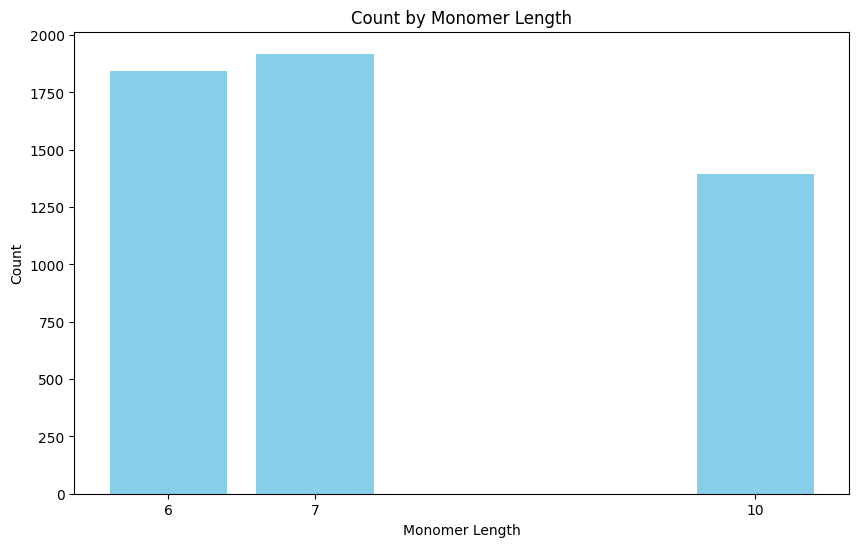

In [10]:
import matplotlib.pyplot as plt

# Monomer_Length별 개수 계산
monomer_counts = df['Monomer_Length'].value_counts().sort_index()

# 막대그래프 그리기
plt.figure(figsize=(10, 6))
plt.bar(monomer_counts.index, monomer_counts.values, color='skyblue')
plt.xlabel('Monomer Length')
plt.ylabel('Count')
plt.title('Count by Monomer Length')
plt.xticks(monomer_counts.index)
plt.show()

Group 1 (length=10, PAMPA >= -6): 858
count    858.000000
mean       0.220654
std        0.190580
min       -0.401000
25%        0.095250
50%        0.199500
75%        0.338000
max        0.853000
Name: PSA_diff, dtype: float64

Group 2 (length>=10, PAMPA <= -6): 547
count    547.000000
mean       0.249501
std        0.199968
min       -0.402000
25%        0.127500
50%        0.235000
75%        0.360000
max        0.939000
Name: PSA_diff, dtype: float64


/home/sohyun/.conda/envs/eda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sohyun/.conda/envs/eda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


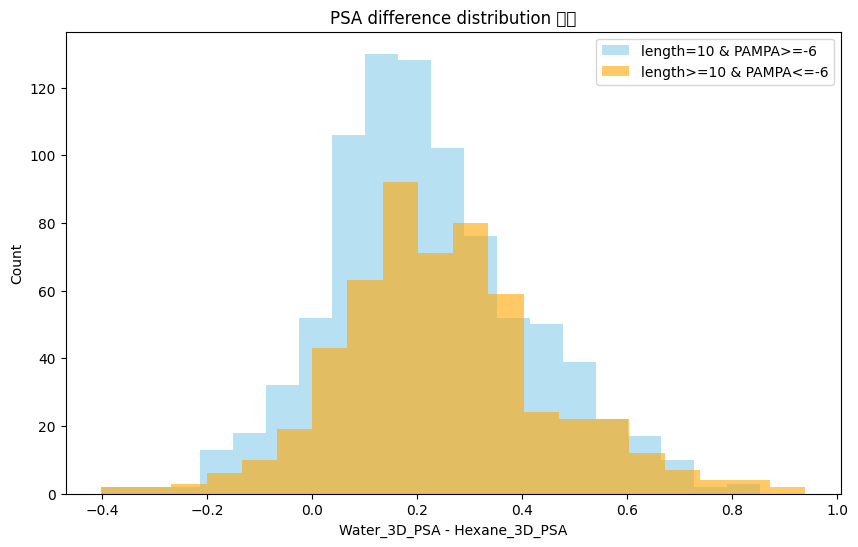

In [11]:
# 그룹 정의
group1 = df[(df['Monomer_Length'] >= 10) & (df['PAMPA'] >= -6)].copy()
group2 = df[(df['Monomer_Length'] >= 10) & (df['PAMPA'] <= -6)].copy()

# 차이값 계산
group1['PSA_diff'] = group1['Water_3D_PSA'] - group1['Hexane_3D_PSA']
group2['PSA_diff'] = group2['Water_3D_PSA'] - group2['Hexane_3D_PSA']

# 개수 및 통계 출력
print("Group 1 (length=10, PAMPA >= -6):", len(group1))
print(group1['PSA_diff'].describe())
print()
print("Group 2 (length>=10, PAMPA <= -6):", len(group2))
print(group2['PSA_diff'].describe())

# 분포 비교 그래프
plt.figure(figsize=(10, 6))
plt.hist(group1['PSA_diff'], bins=20, alpha=0.6, label='length=10 & PAMPA>=-6', color='skyblue')
plt.hist(group2['PSA_diff'], bins=20, alpha=0.6, label='length>=10 & PAMPA<=-6', color='orange')
plt.xlabel('Water_3D_PSA - Hexane_3D_PSA')
plt.ylabel('Count')
plt.title('PSA difference distribution 비교')
plt.legend()
plt.show()

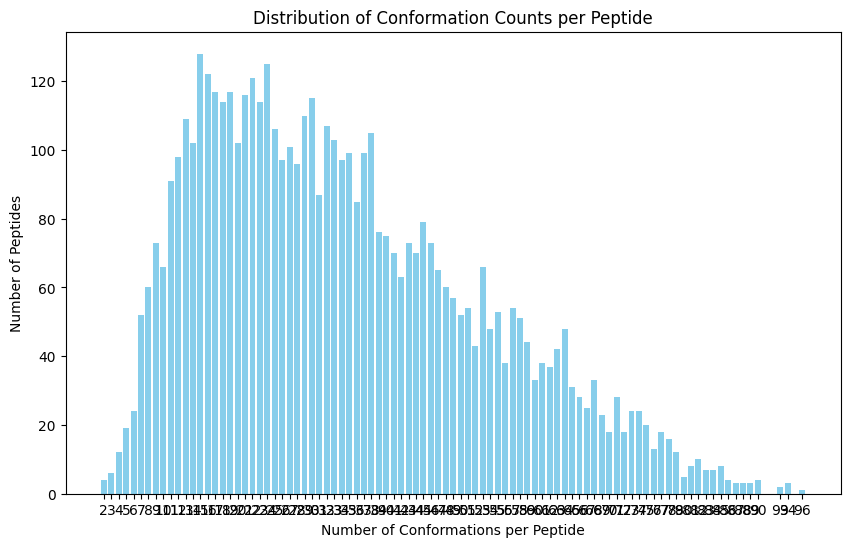

Conformation count distribution:
2 conformations: 4 peptides
3 conformations: 6 peptides
4 conformations: 12 peptides
5 conformations: 19 peptides
6 conformations: 24 peptides
7 conformations: 52 peptides
8 conformations: 60 peptides
9 conformations: 73 peptides
10 conformations: 66 peptides
11 conformations: 91 peptides
12 conformations: 98 peptides
13 conformations: 109 peptides
14 conformations: 102 peptides
15 conformations: 128 peptides
16 conformations: 122 peptides
17 conformations: 117 peptides
18 conformations: 114 peptides
19 conformations: 117 peptides
20 conformations: 102 peptides
21 conformations: 116 peptides
22 conformations: 121 peptides
23 conformations: 114 peptides
24 conformations: 125 peptides
25 conformations: 106 peptides
26 conformations: 97 peptides
27 conformations: 101 peptides
28 conformations: 96 peptides
29 conformations: 110 peptides
30 conformations: 115 peptides
31 conformations: 87 peptides
32 conformations: 107 peptides
33 conformations: 103 peptides

In [14]:
import os
import matplotlib.pyplot as plt
from collections import Counter
import re

# a2m_files 폴더 경로
folder_path = '/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D/Water/Logs'

# 각 파일의 conformation 개수 계산
conformation_counts = []

for filename in os.listdir(folder_path):
    if filename.endswith('.log'):
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'r') as f:
            content = f.read()
            match = re.search(r'Found (\d+) clusters', content)
            if match:
                count = int(match.group(1))
                conformation_counts.append(count)

# 분포 계산
count_distribution = Counter(conformation_counts)

# 막대그래프 그리기
plt.figure(figsize=(10, 6))
plt.bar(count_distribution.keys(), count_distribution.values(), color='skyblue')
plt.xlabel('Number of Conformations per Peptide')
plt.ylabel('Number of Peptides')
plt.title('Distribution of Conformation Counts per Peptide')
plt.xticks(sorted(count_distribution.keys()))
plt.show()

# 통계 출력
print("Conformation count distribution:")
for count, freq in sorted(count_distribution.items()):
    print(f"{count} conformations: {freq} peptides")

/tmp/ipykernel_2424363/1449732254.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([filtered[filtered['Monomer_Length'] == L]['PAMPA'].dropna() for L in lengths],
/home/sohyun/.conda/envs/eda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sohyun/.conda/envs/eda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sohyun/.conda/envs/eda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


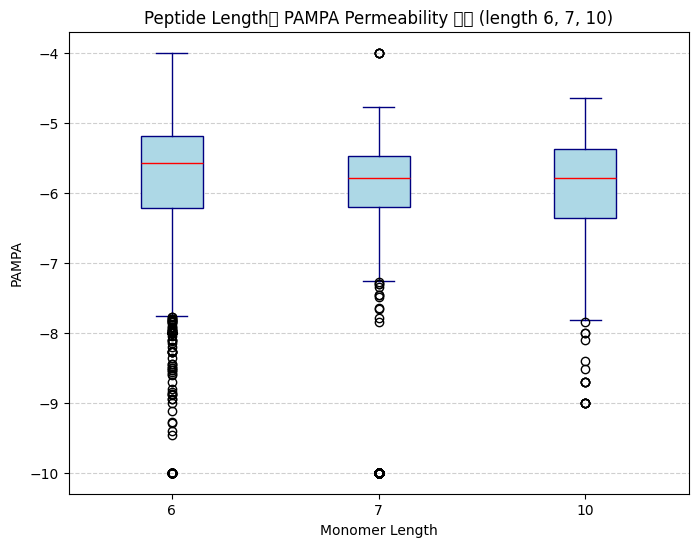

In [15]:
# 길이별 permeability(PAMPA) boxplot
lengths = [6, 7, 10]
filtered = df[df['Monomer_Length'].isin(lengths)].copy()

plt.figure(figsize=(8, 6))
plt.boxplot([filtered[filtered['Monomer_Length'] == L]['PAMPA'].dropna() for L in lengths],
            labels=[str(L) for L in lengths],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='navy'),
            capprops=dict(color='navy'))
plt.xlabel('Monomer Length')
plt.ylabel('PAMPA')
plt.title('Peptide Length별 PAMPA Permeability 분포 (length 6, 7, 10)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

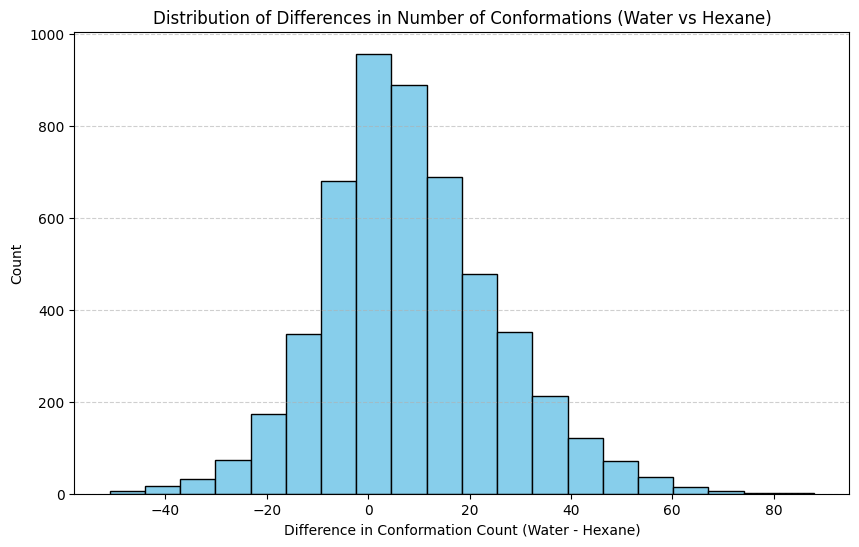

In [3]:
import os
import re
import matplotlib.pyplot as plt

# 폴더 경로
water_logs_path = '/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D/Water/Logs'
hexane_logs_path = '/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D/Hexane/Logs'

# conformation 개수 추출 함수
def get_conformation_counts(logs_path):
    counts = {}
    for filename in os.listdir(logs_path):
        if filename.endswith('.log'):
            peptide_id = filename.split('_')[2]  # 파일 이름에서 ID 추출
            file_path = os.path.join(logs_path, filename)
            with open(file_path, 'r') as f:
                content = f.read()
                match = re.search(r'Found (\d+) clusters', content)
                if match:
                    count = int(match.group(1))
                    counts[peptide_id] = count
    return counts

# 물과 헥세인에서 conformation 개수 얻기
water_counts = get_conformation_counts(water_logs_path)
hexane_counts = get_conformation_counts(hexane_logs_path)

# 같은 펩타이드에 대해 차이 계산
differences = {}
for peptide_id in water_counts:
    if peptide_id in hexane_counts:
        diff = water_counts[peptide_id] - hexane_counts[peptide_id]
        differences[peptide_id] = diff

# 히스토그램 그리기
if differences:
    diffs = list(differences.values())
    
    plt.figure(figsize=(10, 6))
    plt.hist(diffs, bins=20, color='skyblue', edgecolor='black')
    plt.xlabel('Difference in Conformation Count (Water - Hexane)')
    plt.ylabel('Count')
    plt.title('Distribution of Differences in Number of Conformations (Water vs Hexane)')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
else:
    print("No matching peptides found.")

In [4]:
import pandas as pd

def print_zero_difference_peptides(water_counts, hexane_counts, differences):
    """
    difference가 0인 펩타이드들의 ID와 conformation 개수를 표로 출력
    """
    # difference가 0인 펩타이드들 필터링
    zero_diff_peptides = [pep_id for pep_id, diff in differences.items() if diff == 0]
    
    # 데이터 준비
    data = []
    for pep_id in sorted(zero_diff_peptides, key=lambda x: int(x)):
        water_conf = water_counts[pep_id]
        hexane_conf = hexane_counts[pep_id]
        data.append({
            'Peptide_ID': pep_id,
            'Water_Conformations': water_conf,
            'Hexane_Conformations': hexane_conf,
            'Difference': water_conf - hexane_conf
        })
    
    # 데이터프레임 생성 및 출력
    df_zero = pd.DataFrame(data)
    print(f"Total peptides with difference = 0: {len(df_zero)}\n")
    print(df_zero.to_string(index=False))
    
    return df_zero

# 함수 실행
result_df = print_zero_difference_peptides(water_counts, hexane_counts, differences)

Total peptides with difference = 0: 146

Peptide_ID  Water_Conformations  Hexane_Conformations  Difference
      1136                   20                    20           0
      1160                   14                    14           0
      1163                   14                    14           0
      1203                   20                    20           0
      1207                   14                    14           0
      1248                   10                    10           0
      1261                   36                    36           0
      1334                   24                    24           0
      1336                   46                    46           0
      1349                   32                    32           0
      1390                   72                    72           0
      1567                   43                    43           0
      1580                   22                    22           0
      1583                   32    

In [6]:
len(result_df)

146

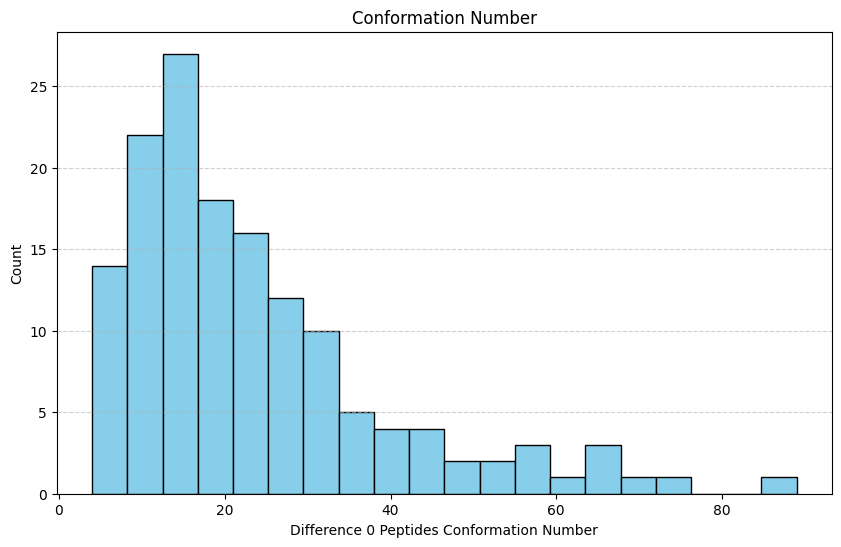

In [7]:
conf_n = list(result_df['Water_Conformations'])

plt.figure(figsize=(10, 6))
plt.hist(conf_n, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Difference 0 Peptides Conformation Number')
plt.ylabel('Count')
plt.title('Conformation Number')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

### Random Forest (csv 파일의 모든 descriptor)

Total samples: 5160
Dataset shape: (5160, 19)

PAMPA 값 통계:
count    5160.00000
mean       -5.98749
std         1.07012
min       -10.00000
25%        -6.24000
50%        -5.74000
75%        -5.34000
max        -4.00000
Name: PAMPA, dtype: float64

결측치 개수:
PAMPA             0
Water_3D_SASA     0
Water_3D_NPSA     0
Water_3D_PSA      0
Hexane_3D_SASA    0
Hexane_3D_NPSA    0
Hexane_3D_PSA     0
dtype: int64

결측치 제거 후 샘플 개수: 5160

Train set size: 4128
Test set size: 1032

RandomForest 모델 성능
Train RMSE: 0.8205
Test RMSE: 1.0342
Train MAE: 0.5203
Test MAE: 0.6523
Train R²: 0.4126
Test R²: 0.0625

Descriptor 기여도 (Feature Importance)
       Feature  Importance
  Water_3D_PSA    0.230297
 Hexane_3D_PSA    0.183077
Hexane_3D_NPSA    0.168741
 Water_3D_NPSA    0.163681
Hexane_3D_SASA    0.132195
 Water_3D_SASA    0.122008


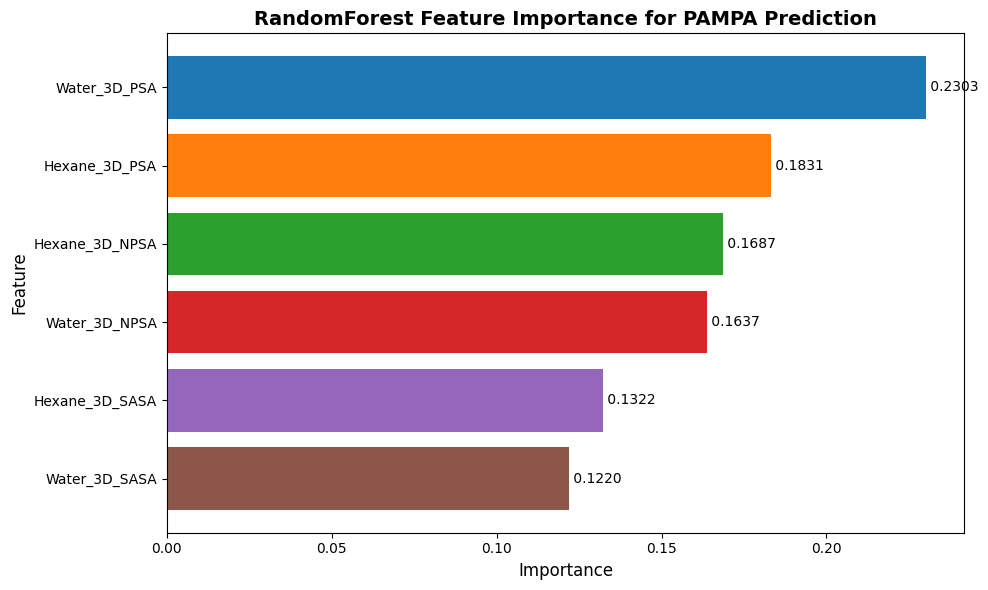

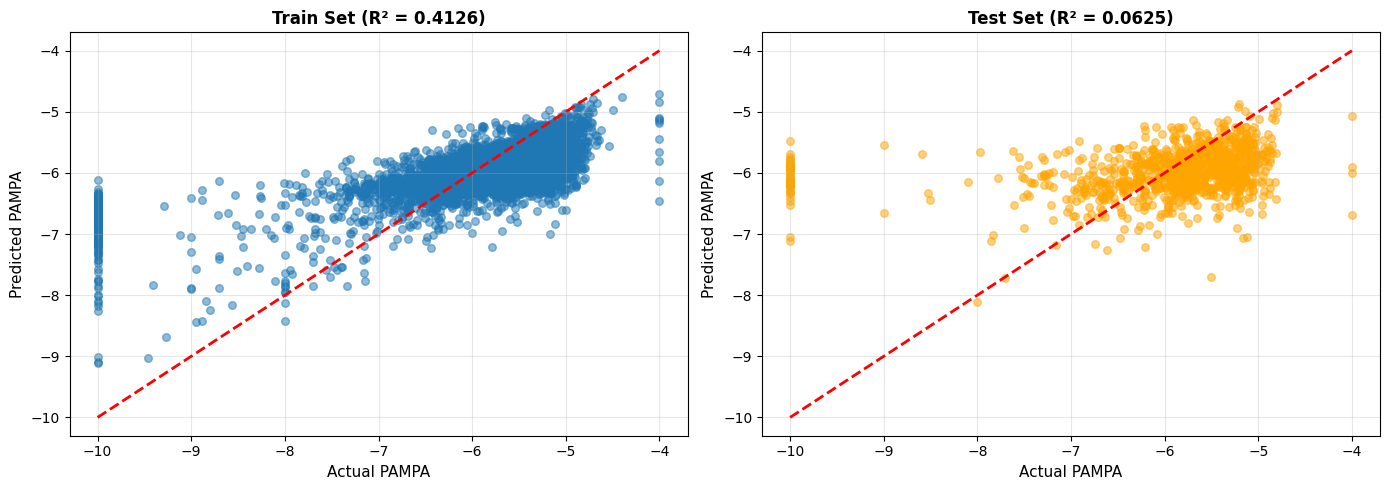

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# 필요한 descriptor 컬럼
descriptor_cols = [
    'Water_3D_SASA', 'Water_3D_NPSA', 'Water_3D_PSA',
    'Hexane_3D_SASA', 'Hexane_3D_NPSA', 'Hexane_3D_PSA'
]

# CSV 파일 읽기
df = pd.read_csv('/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D.csv')

print(f"Total samples: {len(df)}")
print(f"Dataset shape: {df.shape}")
print(f"\nPAMPA 값 통계:")
print(df['PAMPA'].describe())

# 결측치 확인
missing_data = df[['PAMPA'] + descriptor_cols].isnull().sum()
print(f"\n결측치 개수:")
print(missing_data)

# 결측치 제거
df_clean = df[['PAMPA'] + descriptor_cols].dropna()
print(f"\n결측치 제거 후 샘플 개수: {len(df_clean)}")

# 데이터 분할 (train: 80%, test: 20%, random_state 고정)
X = df_clean[descriptor_cols]
y = df_clean['PAMPA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# RandomForest 모델 학습
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 예측
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 모델 성능 평가
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "="*50)
print("RandomForest 모델 성능")
print("="*50)
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# Feature Importance 시각화
feature_importance = pd.DataFrame({
    'Feature': descriptor_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*50)
print("Descriptor 기여도 (Feature Importance)")
print("="*50)
print(feature_importance.to_string(index=False))

# Feature Importance 차트
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('RandomForest Feature Importance for PAMPA Prediction', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# 값을 막대 위에 표시
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    ax.text(row['Importance'], i, f" {row['Importance']:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Actual vs Predicted 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual PAMPA', fontsize=11)
axes[0].set_ylabel('Predicted PAMPA', fontsize=11)
axes[0].set_title(f'Train Set (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual PAMPA', fontsize=11)
axes[1].set_ylabel('Predicted PAMPA', fontsize=11)
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Total samples: 5160
Dataset shape: (5160, 19)

PAMPA 값 통계:
count    5160.00000
mean       -5.98749
std         1.07012
min       -10.00000
25%        -6.24000
50%        -5.74000
75%        -5.34000
max        -4.00000
Name: PAMPA, dtype: float64

결측치 제거 후 샘플 개수: 5160

Train set size: 4128
Val set size: 516
Test set size: 516

RandomForest 모델 성능
Train RMSE: 0.7782 | MAE: 0.4877 | R²: 0.4716
Val   RMSE: 0.9622 | MAE: 0.6146 | R²: 0.1259
Test  RMSE: 1.0316 | MAE: 0.6394 | R²: 0.1268

Descriptor 기여도 (Feature Importance)
                Feature  Importance
Desolvation_Free_Energy    0.168791
               PSA/SASA    0.111136
          Hexane_3D_PSA    0.105131
         Hexane_3D_NPSA    0.104580
         Hexane_3D_SASA    0.093410
          Water_3D_NPSA    0.087968
          Water_3D_SASA    0.070098
           Water_3D_PSA    0.069666
         Monomer_Length    0.053851
              SASA_Norm    0.041310
              SASA_Diff    0.032390
               PSA_Norm    0.032110
         

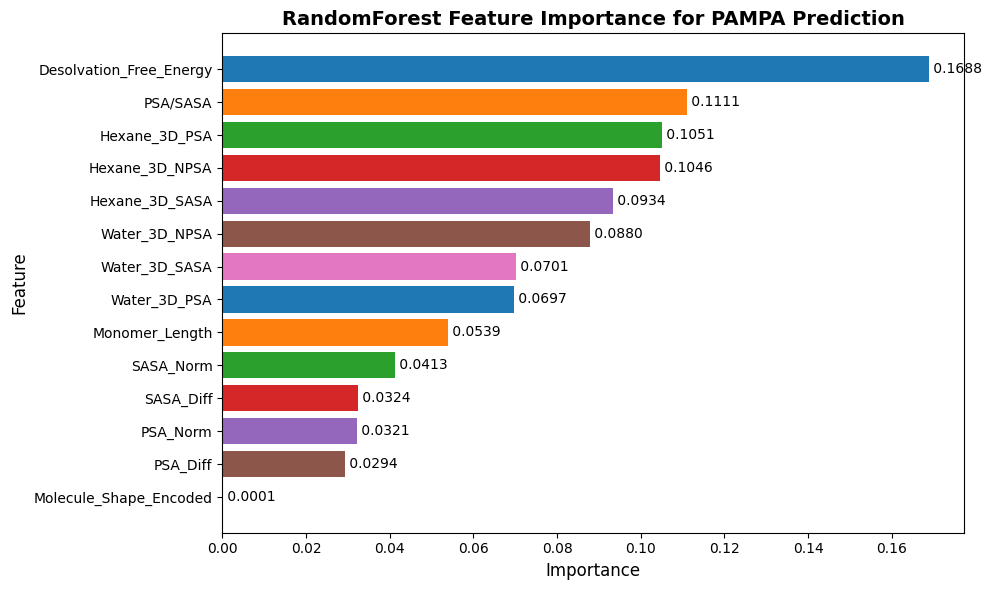

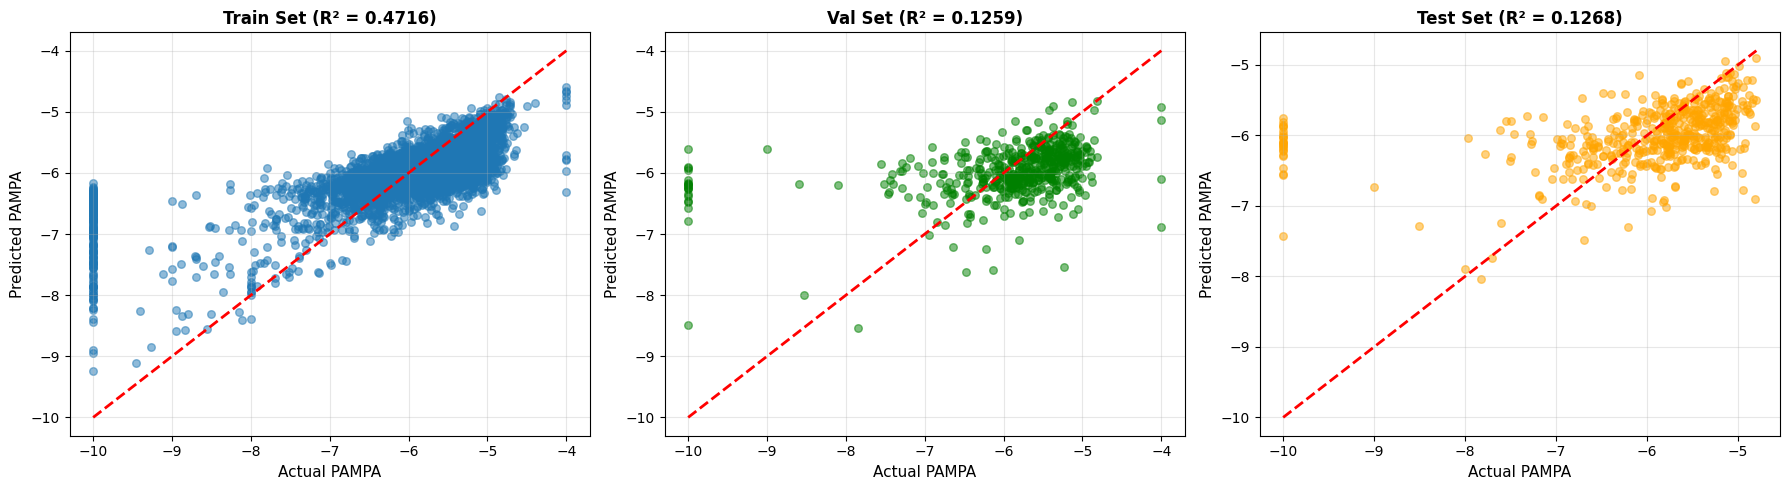

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 필요한 descriptor 컬럼
descriptor_cols = [
    'Water_3D_SASA', 'Water_3D_NPSA', 'Water_3D_PSA',
    'Hexane_3D_SASA', 'Hexane_3D_NPSA', 'Hexane_3D_PSA', 'Monomer_Length', 'Desolvation_Free_Energy', 'Molecule_Shape_Encoded',
    'PSA_Diff', 'SASA_Diff', "PSA_Norm", "SASA_Norm", 'PSA/SASA'
]

# CSV 파일 읽기
df = pd.read_csv('/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D.csv')

print(f"Total samples: {len(df)}")
print(f"Dataset shape: {df.shape}")
print(f"\nPAMPA 값 통계:")
print(df['PAMPA'].describe())

# 결측치 확인
# missing_data = df[['PAMPA'] + descriptor_cols[:-1]].isnull().sum()
# print(f"\n결측치 개수:")
# print(missing_data)

# 결측치 제거 (PSA_Diff는 아직 계산 전이므로 제외)
df_clean = df[['PAMPA'] + descriptor_cols[:-6]].dropna().copy()
print(f"\n결측치 제거 후 샘플 개수: {len(df_clean)}")

# PSA 차이 컬럼 추가
df_clean['Molecule_Shape_Encoded'] = (df['Molecule_Shape'] == 'Circle').astype(int)
df_clean['PSA_Diff'] = df_clean['Water_3D_PSA'] - df_clean['Hexane_3D_PSA']
df_clean['SASA_Diff'] = df_clean['Water_3D_SASA'] - df_clean['Hexane_3D_SASA']
df_clean['PSA_Norm'] = df_clean['Water_3D_PSA'] / df_clean['Hexane_3D_PSA']
df_clean['SASA_Norm'] = df_clean['Water_3D_SASA'] / df_clean['Hexane_3D_SASA']
df_clean['PSA/SASA'] = df_clean['Water_3D_PSA'] / df_clean['Water_3D_SASA']


# 데이터 분할 (train: 60%, val: 20%, test: 20%, random_state 고정)
X = df_clean[descriptor_cols]
y = df_clean['PAMPA']

# 첫 번째 분할: train 60%, temp 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 두 번째 분할: temp를 val 50%, test 50%로 분할
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"\nTrain set size: {len(X_train)}")
print(f"Val set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

# RandomForest 모델 학습
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 예측
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

# 모델 성능 평가
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\n" + "="*50)
print("RandomForest 모델 성능")
print("="*50)
print(f"Train RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R²: {train_r2:.4f}")
print(f"Val   RMSE: {val_rmse:.4f} | MAE: {val_mae:.4f} | R²: {val_r2:.4f}")
print(f"Test  RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

# Feature Importance 시각화
feature_importance = pd.DataFrame({
    'Feature': descriptor_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*50)
print("Descriptor 기여도 (Feature Importance)")
print("="*50)
print(feature_importance.to_string(index=False))

# Feature Importance 차트
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('RandomForest Feature Importance for PAMPA Prediction', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# 값을 막대 위에 표시
for i, (idx, row) in enumerate(feature_importance.iterrows()):
    ax.text(row['Importance'], i, f" {row['Importance']:.4f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Actual vs Predicted 시각화 (Train / Val / Test)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual PAMPA', fontsize=11)
axes[0].set_ylabel('Predicted PAMPA', fontsize=11)
axes[0].set_title(f'Train Set (R² = {train_r2:.4f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Val set
axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=30, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual PAMPA', fontsize=11)
axes[1].set_ylabel('Predicted PAMPA', fontsize=11)
axes[1].set_title(f'Val Set (R² = {val_r2:.4f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual PAMPA', fontsize=11)
axes[2].set_ylabel('Predicted PAMPA', fontsize=11)
axes[2].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Sequence 추출 -> Non-canonical로 인해 실패

In [ ]:
import os
import re

# 아미노산 3글자 코드 -> 1글자 코드 변환 딕셔너리
AA_CODE_3TO1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V'
}

def extract_sequence_from_pdb(pdb_file_path):
    """
    PDB 파일에서 아미노산 시퀀스 추출
    """
    sequence = []
    prev_residue_num = None
    
    try:
        with open(pdb_file_path, 'r') as f:
            for line in f:
                # ATOM 라인 읽기
                if line.startswith('ATOM'):
                    # 잔기 이름 추출 (17-20 위치)
                    residue_name = line[17:20].strip()
                    # 잔기 번호 추출 (22-26 위치)
                    residue_num = int(line[22:26].strip())
                    
                    # 새로운 잔기일 때만 추가 (중복 방지)
                    if residue_num != prev_residue_num:
                        if residue_name in AA_CODE_3TO1:
                            sequence.append(AA_CODE_3TO1[residue_name])
                        prev_residue_num = residue_num
    except Exception as e:
        print(f"Error reading {pdb_file_path}: {e}")
        return ""
    
    return ''.join(sequence)

# CSV 읽기
df = pd.read_csv('/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D.csv')
print(f"Original CSV shape: {df.shape}")

# 시퀀스 추출
pdb_dir = '/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D/Water/Structures'
sequences = {}

print("\n시퀀스 추출 중...")
for idx, row in df.iterrows():
    pdb_id = row['CycPeptMPDB_ID']
    source = row['Source']
    
    # PDB 파일명 구성 (Source_ID_H2O_Str.pdb)
    pdb_file_name = f"{source}_{pdb_id}_H2O_Str.pdb"
    pdb_file_path = os.path.join(pdb_dir, pdb_file_name)
    
    if os.path.exists(pdb_file_path):
        sequence = extract_sequence_from_pdb(pdb_file_path)
        sequences[pdb_id] = sequence
    else:
        sequences[pdb_id] = ""
    
    if (idx + 1) % 500 == 0:
        print(f"  {idx + 1}/{len(df)} 완료")

print(f"\n성공적으로 추출한 시퀀스: {sum(1 for s in sequences.values() if s)}/{len(sequences)}")

# CSV에 시퀀스 컬럼 추가
df['Sequence'] = df['CycPeptMPDB_ID'].map(sequences)

# 시퀀스 길이 확인
df['Sequence_Length'] = df['Sequence'].str.len()

print("\n시퀀스 정보 통계:")
print(df[['Sequence', 'Sequence_Length', 'Monomer_Length']].describe())
print("\n샘플 시퀀스 (처음 5개):")
print(df[['CycPeptMPDB_ID', 'Sequence', 'Sequence_Length', 'Monomer_Length']].head())

# 수정된 CSV 저장
df.to_csv('/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D_sequences.csv', index=False)
print("\n✓ 시퀀스가 포함된 CSV 저장 완료: CycPeptMPDB-4D_sequences.csv")

Original CSV shape: (5160, 19)

시퀀스 추출 중...
  500/5160 완료
  1000/5160 완료
  1500/5160 완료
  2000/5160 완료
  2500/5160 완료
  3000/5160 완료
  3500/5160 완료
  4000/5160 완료
  4500/5160 완료
  5000/5160 완료

성공적으로 추출한 시퀀스: 5160/5160

시퀀스 정보 통계:
       Sequence_Length  Monomer_Length
count      5160.000000     5160.000000
mean          4.137209        7.454070
std           1.382670        1.608342
min           1.000000        6.000000
25%           3.000000        6.000000
50%           4.000000        7.000000
75%           5.000000       10.000000
max           8.000000       10.000000

샘플 시퀀스 (처음 5개):
   CycPeptMPDB_ID Sequence  Sequence_Length  Monomer_Length
0            7067      PLP                3              10
1            7066      PLP                3              10
2            7065      PLP                3              10
3            7064      PLP                3              10
4            7063      PLP                3              10

✓ 시퀀스가 포함된 CSV 저장 완료: CycPeptMPDB-4D_wit

### Residue Types

In [4]:
import os
import re
from collections import Counter, defaultdict
from tqdm import tqdm

pdb_dir = '/ssd0/sohyun/cyclic_peptide_permeability/CycPeptMPDB-4D/Water/Structures'

def extract_residues_from_pdb(pdb_file_path):
    """
    PDB 파일에서 residue name을 추출.
    같은 residue 번호에 대해 중복 ATOM line은 1번만 세도록 처리.
    
    Returns:
        residues_in_file: 파일 내 residue sequence list
    """
    residues_in_file = []
    seen_residues = set()  # (chain_id, residue_num, residue_name)

    try:
        with open(pdb_file_path, 'r') as f:
            for line in f:
                if line.startswith('ATOM'):
                    residue_name = line[17:20].strip()
                    chain_id = line[21].strip()
                    residue_num = line[22:26].strip()

                    residue_key = (chain_id, residue_num, residue_name)
                    if residue_key not in seen_residues:
                        seen_residues.add(residue_key)
                        residues_in_file.append(residue_name)

    except Exception as e:
        print(f"Error reading {pdb_file_path}: {e}")
        return []

    return residues_in_file


# 전체 통계용
vocab_counter = Counter()              # 전체 residue 출현 횟수
file_occurrence_counter = Counter()    # residue가 등장한 파일 수
files_by_residue = defaultdict(list)   # residue별 등장 파일 목록

pdb_files = [f for f in os.listdir(pdb_dir) if f.endswith('.pdb')]
print(f"총 PDB 파일 수: {len(pdb_files)}")

for pdb_file in tqdm(sorted(pdb_files), total=len(pdb_files)):
    pdb_file_path = os.path.join(pdb_dir, pdb_file)
    residues_in_file = extract_residues_from_pdb(pdb_file_path)

    # 전체 출현 횟수
    vocab_counter.update(residues_in_file)

    # 파일 단위 등장 여부
    unique_residues_in_file = set(residues_in_file)
    for residue in unique_residues_in_file:
        file_occurrence_counter[residue] += 1
        files_by_residue[residue].append(pdb_file)

# 전체 vocab
all_vocab = sorted(vocab_counter.keys())

print("\n=== 전체 residue vocab ===")
print(all_vocab)
print(f"\n전체 residue 종류 수: {len(all_vocab)}")

print("\n=== residue별 통계 ===")
print(f"{'Residue':<8} {'Total_Count':>12} {'File_Count':>12}")
for residue in sorted(all_vocab):
    print(f"{residue:<8} {vocab_counter[residue]:>12} {file_occurrence_counter[residue]:>12}")

# A## 패턴만 따로 보기
a_code_vocab = sorted(
    [res for res in all_vocab if re.fullmatch(r'A\d{2}', res)],
    key=lambda x: int(x[1:])
)

normal_vocab = sorted([res for res in all_vocab if not re.fullmatch(r'A\d{2}', res)])

print("\n=== A## 형태 residue vocab ===")
print(a_code_vocab)
print(f"A## residue 종류 수: {len(a_code_vocab)}")

print("\n=== 일반 residue vocab ===")
print(normal_vocab)
print(f"일반 residue 종류 수: {len(normal_vocab)}")

# 최대 A코드 확인
if a_code_vocab:
    max_a_code = max(a_code_vocab, key=lambda x: int(x[1:]))
    print(f"\n최대 A코드: {max_a_code}")
else:
    print("\nA## 형태 residue는 없습니다.")

# 필요하면 CSV로 저장
output_path = '/ssd0/sohyun/cyclic_peptide_permeability/water_residue_vocab.csv'
with open(output_path, 'w') as f:
    f.write("Residue,Total_Count,File_Count\n")
    for residue in sorted(all_vocab):
        f.write(f"{residue},{vocab_counter[residue]},{file_occurrence_counter[residue]}\n")

print(f"\n✓ residue vocab 통계 저장 완료: {output_path}")

총 PDB 파일 수: 5160


  0%|          | 0/5160 [00:00<?, ?it/s]

100%|██████████| 5160/5160 [00:00<00:00, 12739.69it/s]


=== 전체 residue vocab ===
['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'ABU', 'ACE', 'ALA', 'ARG', 'ASN', 'BHF', 'CHA', 'GLY', 'ILE', 'LEU', 'LYS', 'MAB', 'MAL', 'MCH', 'MGL', 'MLE', 'MNV', 'MPH', 'MTH', 'MTR', 'MTY', 'NAL', 'NBZ', 'NLE', 'NPR', 'NVA', 'PHE', 'PRO', 'THR', 'TNH', 'TRP', 'TYR', 'VAL']

전체 residue 종류 수: 53

=== residue별 통계 ===
Residue   Total_Count   File_Count
A01               136          136
A02                40           40
A03                40           40
A04               136          136
A05                40           40
A06                40           40
A07                40           40
A08               136          136
A09                40           40
A10                40           40
A11                40           40
A12               136          136
A13                40           40
A14               136          136
A15               136          136
